# ProstT5 Speculative Decoding — ProtProfileMD 3Di-FlexProfile Drafter (AA → 3Di)

**Folding direction:** amino acid sequence → 3Di structural tokens.

**Drafter:** [ProtProfileMD](https://doi.org/10.64898/2026.01.21.700698) (`finnlueth/ProtProfileMD`) — ProstT5 encoder + LoRA + linear head; trained with KL divergence to MD-derived **3Di-FlexProfiles** (PPMs over the 20-letter 3Di alphabet).

**Verifier:** full ProstT5 enc-dec (`Rostlab/ProstT5_fp16`), identical to `model.generate(do_sample=False)`.

Mirrors `prostT5_speculative_decoding_viet.ipynb` (CNN, 3Di→AA) for the flex-profile drafter:

1. One-shot FlexProfile argmax vs enc-dec vs AFDB 3Di  
2. Greedy speculative decoding (KV-cache)  
3. K sweep, speedup, draft-slot acceptance  
4. **HuggingFace `assistant_model`** — `FlexProfileAssistantModel` in `flexprofile_drafter.py`
5. **Part 5** — HF `assistant_model` K-sweep benchmark (standalone)

**Note:** `draft_acceptance_rate` is not baseline Leviathan α. K=1 ≈ static enc-dec↔flex argmax agreement; K>1 is lower (prefix-independent profiles).


In [1]:
%pip install -q tiktoken sentencepiece torch
%pip install -q 'accelerate>=0.26.0'
%pip install -q "transformers==4.46.3" "protobuf>=3.20,<5" sentencepiece
%pip install -q peft safetensors pyyaml huggingface_hub datasets pandas matplotlib

# Do NOT upgrade transformers to 5.x — breaks ProstT5 T5Tokenizer.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 77.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [2]:
# @title Runtime paths — Colab (Drive) | Kaggle (Dataset) | local
import os
from pathlib import Path

os.environ["USE_TF"] = "0"

# ── Kaggle: add a Dataset built from your Drive files (Drive cannot mount like Colab) ──
# 1. On Drive, zip or copy: benchmark_data/, cnn checkpoint (if needed), this repo's .py files
# 2. kaggle.com → Datasets → New Dataset → upload
# 3. Notebook → Add Data → your dataset
# 4. Set slug below (folder name under /kaggle/input/)
KAGGLE_DATASET_SLUG = "datasets/ebrarkzlgl/fasta-proteins"  # <-- edit before running on Kaggle

RUNTIME = "local"
USE_DRIVE = False
DRIVE_ROOT = None
WORK_DIR = None  # writable output root (Kaggle: /kaggle/working)

if os.path.isdir("/kaggle/input"):
    RUNTIME = "kaggle"
    kaggle_root = Path("/kaggle/input") / KAGGLE_DATASET_SLUG
    if not kaggle_root.exists():
        # fallback: first attached dataset
        subs = sorted(Path("/kaggle/input").iterdir())
        kaggle_root = subs[0] if subs else kaggle_root
        print(f"WARNING: {KAGGLE_DATASET_SLUG} not found; using {kaggle_root}")
    WORK_DIR = Path("/kaggle/working")
    DRIVE_ROOT = str(kaggle_root)  # read-only input (same role as Drive on Colab)
    USE_DRIVE = True
    os.environ.setdefault("HF_HOME", str(WORK_DIR / "hf_cache"))
    (WORK_DIR / "hf_cache").mkdir(parents=True, exist_ok=True)
    print(f"Kaggle: input={kaggle_root}  output={WORK_DIR}")

else:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        RUNTIME = "colab"
        DRIVE_ROOT = "/content/drive/MyDrive"
        USE_DRIVE = True
        WORK_DIR = Path(DRIVE_ROOT)
        os.environ.setdefault("HF_HOME", str(WORK_DIR / "hf_cache"))
        print("Colab: Google Drive mounted.")
    except Exception:
        RUNTIME = "local"
        USE_DRIVE = False
        DRIVE_ROOT = None
        WORK_DIR = None
        print("Local: use paths next to this notebook (no Drive).")

Kaggle: input=/kaggle/input/datasets/ebrarkzlgl/fasta-proteins  output=/kaggle/working


In [3]:
"""
FlexProfile drafter utilities for speculative decoding (AA → 3Di folding direction).

Loads ProtProfileMD (ProstT5 encoder + LoRA + linear profile head) from HuggingFace
and provides draft logits for speculative decoding with the ProstT5 enc-dec verifier.
"""
import os, re, yaml
import torch
import torch.nn as nn
from transformers import GenerationConfig, PreTrainedModel, T5EncoderModel, T5Tokenizer
from transformers.modeling_outputs import Seq2SeqLMOutput
from peft import PeftModel, LoraConfig, get_peft_model

# 3Di structural alphabet (same letters as AA but lowercase, alphabetical order)
DI_LETTERS = "acdefghiklmnpqrstvwy"
assert len(DI_LETTERS) == 20


class ProfileHeadLinear(nn.Module):
    """Linear head for profile generation from T5 embeddings.
    Mirrors ProtProfileMD's ProfileHeadLinear exactly."""
    def __init__(self, dropout=0.1, hidden_size=1024, num_classes=20):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.dropout(x)
        x = self.classifier(x)
        x = torch.softmax(x, dim=2)
        return x


class FlexProfileDrafter(nn.Module):
    """Wraps ProstT5 encoder + LoRA + profile head to produce 3Di draft logits.

    The ProtProfileMD model predicts per-residue probability distributions over
    20 3Di states from an AA sequence. We use these as draft distributions for
    speculative decoding in the folding direction.
    """
    def __init__(self, device="cpu", dtype=torch.float32):
        super().__init__()
        self.device = device
        self.dtype = dtype
        self._encoder = None
        self._profile_head = None

        
    @classmethod
    def from_huggingface(cls, device="cpu", dtype=torch.float32):
        """Load ProtProfileMD (ProstT5 encoder + LoRA + trained profile head) from the Hub."""
        from huggingface_hub import snapshot_download
        import safetensors.torch
        from peft import LoraConfig, get_peft_model

        drafter = cls(device=device, dtype=dtype)

        # FIX 1: download the WHOLE repo, not just one file, so the adapter folder exists.
        repo_dir = snapshot_download(repo_id="finnlueth/ProtProfileMD")

        with open(os.path.join(repo_dir, "train_config.yaml"), "r") as f:
            train_config = yaml.safe_load(f)

        adapter_name = train_config["metadata"]["adapter_name"]   # "ProtProfileMD_LoRA"
        adapter_dir = os.path.join(repo_dir, adapter_name)
        st_path = os.path.join(adapter_dir, "adapter_model.safetensors")  # FIX 2: correct filename

        print(f"ProtProfileMD repo: {repo_dir}")
        print(f"  Base model:   {train_config['model']['base_model']}")
        print(f"  Profile head: {train_config['model']['profile_head']}")

        # 1. Base ProstT5 encoder (fp16 weights are numerically the same model as the
        #    fp32 ProstT5 the LoRA was trained on; fine for a drafter).
        from transformers import T5EncoderModel
        print("Loading ProstT5 encoder for ProtProfileMD...")
        encoder = T5EncoderModel.from_pretrained(
            "Rostlab/ProstT5_fp16", torch_dtype=dtype, low_cpu_mem_usage=True,
        )

        # 2. Profile head (the linear classifier).  ProfileHeadLinear must already be defined.
        profile_head = ProfileHeadLinear(**train_config["model"]["profile_head_kwargs"])

        # 3. Attach LoRA to the encoder. We drop modules_to_save here because the head is
        #    kept as a separate module (loaded manually in step 5), not inside the encoder.
        lora_cfg = train_config["training"]["lora"].copy()
        lora_cfg.pop("modules_to_save", None)
        encoder = get_peft_model(encoder, peft_config=LoraConfig(**lora_cfg),
                                adapter_name=adapter_name)

        # 4. Load the LoRA (q/v) weights. adapter_dir now exists thanks to FIX 1.
        #    The profile_head keys in the safetensors are simply ignored here (they don't
        #    match the encoder's modules) -- we load them explicitly in step 5.
        assert os.path.isdir(adapter_dir), f"adapter dir missing: {adapter_dir}"
        encoder.load_adapter(model_id=adapter_dir, adapter_name=adapter_name)
        print(f"  LoRA adapter loaded from {adapter_dir}")

        # 5. Load the TRAINED profile-head weights out of adapter_model.safetensors.
        #    With modules_to_save, PEFT stores the trained copy under keys containing
        #    ".modules_to_save.<adapter_name>." (the ".original_module." copy is the
        #    frozen init -- we must NOT use that one).
        assert os.path.exists(st_path), f"weights file missing: {st_path}"
        state = safetensors.torch.load_file(st_path)

        def _find_head_key(target):  # target e.g. "classifier.weight"
            cands = [k for k in state if "profile_head" in k and k.endswith(target)]
            trained = [k for k in cands if "modules_to_save" in k]
            chosen = trained or cands
            return chosen[0] if chosen else None

        head_state = {}
        for target in profile_head.state_dict().keys():        # classifier.weight, classifier.bias
            k = _find_head_key(target)
            if k is not None:
                head_state[target] = state[k]

        missing = set(profile_head.state_dict().keys()) - set(head_state.keys())
        if missing:
            raise RuntimeError(
                f"Profile-head weights not found in {st_path}: missing {sorted(missing)}.\n"
                f"profile_head-related keys present: "
                f"{[k for k in state if 'profile_head' in k]}"
            )
        profile_head.load_state_dict(head_state, strict=True)
        print(f"  Profile head loaded ({len(head_state)} tensors) from {os.path.basename(st_path)}")

        # 6. Sanity guard: the head is no longer at random init. A freshly-initialized
        #    nn.Linear(1024, 20) has weight std ~ 1/sqrt(1024) ~ 0.031. Trained weights
        #    look different; this catches a silent "didn't actually load" regression.
        w = profile_head.classifier.weight.detach().float()
        print(f"  Head weight: shape={tuple(w.shape)}  mean={w.mean():.4f}  std={w.std():.4f}")
        assert w.abs().sum() > 0, "profile head weights are all zero -- load failed"

        # 7. Merge LoRA into the encoder for faster inference.
        encoder = encoder.merge_and_unload()
        print("  LoRA merged into encoder.")

        drafter._encoder = encoder.to(device).eval()
        drafter._profile_head = profile_head.to(device).eval()

        n_enc = sum(p.numel() for p in encoder.parameters())
        n_head = sum(p.numel() for p in profile_head.parameters())
        print(f"  Encoder params: {n_enc/1e6:.1f}M, Head params: {n_head:,}")
        return drafter


    @torch.inference_mode()
    def predict_profiles(self, input_ids, attention_mask):
        """Run encoder + profile head, return (L, 20) probability profiles.

        Args:
            input_ids: tokenized AA input with <AA2fold> prefix, shape (1, seq_len)
            attention_mask: shape (1, seq_len)

        Returns:
            probs: (L, 20) softmax probabilities over 3Di states
        """
        enc_out = self._encoder(input_ids=input_ids,
                                 attention_mask=attention_mask,
                                 return_dict=True)
        hidden = enc_out.last_hidden_state  # (1, seq_len, 1024)

        # Trim prefix token and EOS — ProtProfileMD trims first token and sets
        # last-token mask to 0; we trim first and last.
        hidden_trimmed = hidden[:, 1:-1, :]  # (1, L, 1024)

        probs = self._profile_head(hidden_trimmed.float())  # (1, L, 20)
        return probs[0]  # (L, 20)

    @torch.inference_mode()
    def get_draft_logits(self, input_ids, attention_mask):
        """Get draft log-probabilities for speculative decoding.

        Returns:
            log_probs: (L, 20) log-probabilities over 3Di states
        """
        probs = self.predict_profiles(input_ids, attention_mask)
        return torch.log(probs + 1e-10)  # convert to log-probs

    @torch.inference_mode()
    def predict_profiles_for_aa_sequence(self, tokenizer, aa_seq: str):
        """Tokenize AA (folding prompt) and return (L, 20) 3Di profile probabilities."""
        text = "<AA2fold> " + " ".join(list(aa_seq.upper()))
        enc = tokenizer([text], add_special_tokens=True, return_tensors="pt")
        enc = {k: v.to(self.device) for k, v in enc.items()}
        return self.predict_profiles(enc["input_ids"], enc["attention_mask"])


def build_3di_token_maps(tokenizer):
    """Map between ProtProfileMD 3Di class index and ProstT5 vocab token ids."""
    token_ids = []
    for letter in DI_LETTERS:
        tid = tokenizer.encode(f" {letter}", add_special_tokens=False)[0]
        token_ids.append(tid)
    idx_to_tid = {i: tid for i, tid in enumerate(token_ids)}
    tid_to_idx = {tid: i for i, tid in enumerate(token_ids)}
    return token_ids, idx_to_tid, tid_to_idx


class FlexProfileAssistantModel(PreTrainedModel):
    """HF `assistant_model` for ProtProfileMD (encoder + profile head, no decoder).

    Overrides `generate()` to emit K argmax 3Di drafts from the fixed PPM; `forward()`
    exposes the same logits for assisted verification.
    """

    def __init__(self, config, flex_drafter: FlexProfileDrafter, di_token_ids: list[int]):
        super().__init__(config)
        self._flex = flex_drafter
        self._di_token_ids = di_token_ids
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=8,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._cached_logits = None
        self._cached_hidden_id = None

    @property
    def device(self):
        return self._flex.device

    def get_encoder(self):
        return self._flex._encoder

    @staticmethod
    def _hidden_tensor(encoder_outputs):
        if hasattr(encoder_outputs, "last_hidden_state"):
            return encoder_outputs.last_hidden_state
        return encoder_outputs[0]

    def _full_vocab_logits(self, encoder_outputs):
        h = self._hidden_tensor(encoder_outputs)[:, 1:-1, :]
        probs = self._flex._profile_head(h.float())[0]
        vocab_size = self.config.vocab_size
        full = torch.full(
            (probs.shape[0], vocab_size), -1e4,
            device=probs.device, dtype=probs.dtype,
        )
        for di_idx, tok_id in enumerate(self._di_token_ids):
            full[:, tok_id] = probs[:, di_idx]
        return full

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        if encoder_outputs is not None:
            h_id = id(self._hidden_tensor(encoder_outputs))
            if self._cached_hidden_id != h_id:
                self._cached_logits = self._full_vocab_logits(encoder_outputs)
                self._cached_hidden_id = h_id
        n = decoder_input_ids.shape[1]
        if self._cached_logits is not None:
            n_ret = min(n, self._cached_logits.shape[0])
            logits = self._cached_logits[:n_ret].unsqueeze(0)
            if n_ret < n:
                pad = torch.full(
                    (1, n - n_ret, logits.shape[-1]), -1e4,
                    device=logits.device, dtype=logits.dtype,
                )
                logits = torch.cat([logits, pad], dim=1)
        else:
            logits = torch.zeros(
                1, n, self.config.vocab_size,
                device=self.device, dtype=torch.float32,
            )
        return Seq2SeqLMOutput(logits=logits)

    @torch.inference_mode()
    def generate(
        self,
        inputs=None,
        generation_config=None,
        logits_processor=None,
        stopping_criteria=None,
        synced_gpus=None,
        streamer=None,
        **kwargs,
    ):
        from transformers.generation.utils import GenerateEncoderDecoderOutput

        generation_config = generation_config or self.generation_config
        decoder_input_ids = kwargs.pop("decoder_input_ids", None)
        if decoder_input_ids is None:
            decoder_input_ids = kwargs.pop("input_ids", inputs)
        encoder_outputs = kwargs.get("encoder_outputs")
        max_new_tokens = int(kwargs.get("max_new_tokens", generation_config.num_assistant_tokens))
        return_dict = kwargs.get("return_dict_in_generate", True)
        output_scores = kwargs.get("output_scores", True)

        if decoder_input_ids is None:
            raise ValueError("FlexProfileAssistantModel.generate requires decoder_input_ids")

        full_logits = self._full_vocab_logits(encoder_outputs)
        pos = decoder_input_ids.shape[1] - 1
        new_tokens = []
        scores = ()
        for i in range(max_new_tokens):
            p = pos + i
            if p >= full_logits.shape[0]:
                break
            logit_vec = full_logits[p]
            new_tokens.append(int(logit_vec.argmax().item()))
            if output_scores:
                scores = scores + (logit_vec.unsqueeze(0).unsqueeze(0),)

        if new_tokens:
            ext = torch.tensor([new_tokens], device=decoder_input_ids.device, dtype=decoder_input_ids.dtype)
            sequences = torch.cat([decoder_input_ids, ext], dim=-1)
        else:
            sequences = decoder_input_ids

        if return_dict:
            return GenerateEncoderDecoderOutput(sequences=sequences, scores=scores or None)
        return sequences


In [4]:
# @title Imports
import os, sys, time, pickle, statistics
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM

if RUNTIME == "kaggle":
    NOTEBOOK_DIR = WORK_DIR / "prostT5"
    NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
    # Copy repo .py into working dir if missing (upload prostT5/ as part of your Kaggle dataset)
    _src = Path("/kaggle/input") / KAGGLE_DATASET_SLUG / "prostT5"
    if _src.exists():
        import shutil
        for name in ("flexprofile_drafter.py",):
            if (_src / name).exists() and not (NOTEBOOK_DIR / name).exists():
                shutil.copy(_src / name, NOTEBOOK_DIR / name)
else:
    NOTEBOOK_DIR = Path(".").resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"torch={torch.__version__}  device={device}")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
BLUE, ORANGE, GRAY = "#2e86de", "#f39c12", "#7f8c8d"

torch=2.10.0+cu128  device=cuda:0


In [5]:
# @title Configuration
PROSTT5_NAME = "Rostlab/ProstT5_fp16"

_base = WORK_DIR if WORK_DIR is not None else NOTEBOOK_DIR
RESULTS_DIR = _base / "benchmark_results/flexprofile"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CHECKPOINT_DIR / "flexprofile_spec_decode.pkl"

K_VALUES = [1, 2, 4, 8]
HF_K = 4
NUM_PROTEINS = 20 # 10
NUM_WARMUP = 1
NUM_REPEATS = 3
USE_FP16 = True

print(f"Runtime: {RUNTIME}  |  Results: {RESULTS_DIR}")
print(f"K_VALUES={K_VALUES}  HF_K={HF_K}  NUM_PROTEINS={NUM_PROTEINS}")
if RUNTIME == "kaggle":
    print("Download outputs: Kaggle → Notebook → Output → benchmark_results/flexprofile/")

Runtime: kaggle  |  Results: /kaggle/working/benchmark_results/flexprofile
K_VALUES=[1, 2, 4, 8]  HF_K=4  NUM_PROTEINS=20
Download outputs: Kaggle → Notebook → Output → benchmark_results/flexprofile/


In [6]:
# @title Load ProstT5 (verifier) + ProtProfileMD (drafter)
tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(
    PROSTT5_NAME, low_cpu_mem_usage=True, torch_dtype=dtype,
).to(device).eval()
if dtype == torch.float16:
    model = model.half()
encoder = model.get_encoder()

DI_TOKEN_IDS, DI_IDX_TO_TOKEN_ID, DI_TOKEN_ID_TO_IDX = build_3di_token_maps(tokenizer)
DECODER_START_TOKEN_ID = model.config.decoder_start_token_id

for di, tid in zip(DI_LETTERS[:3], DI_TOKEN_IDS[:3]):
    assert tokenizer.decode([tid]).strip().lower() == di

print("Loading ProtProfileMD (FlexProfile drafter from HuggingFace)...")
flex_drafter = FlexProfileDrafter.from_huggingface(device=device, dtype=dtype)
print(f"ProstT5 verifier: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

...

train_config.yaml: 0.00B [00:00, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

training_history.png:   0%|          | 0.00/53.9k [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

ProtProfileMD repo: /kaggle/working/hf_cache/hub/models--finnlueth--ProtProfileMD/snapshots/16be78ef5c7db694f426371c593548bfdfbb335e
  Base model:   Rostlab/ProstT5
  Profile head: linear
Loading ProstT5 encoder for ProtProfileMD...
  LoRA adapter loaded from /kaggle/working/hf_cache/hub/models--finnlueth--ProtProfileMD/snapshots/16be78ef5c7db694f426371c593548bfdfbb335e/ProtProfileMD_LoRA
  Profile head loaded (2 tensors) from adapter_model.safetensors
  Head weight: shape=(20, 1024)  mean=0.0002  std=0.0404
  LoRA merged into encoder.
  Encoder params: 1208.2M, Head params: 20,500
ProstT5 verifier: 2818.9M params


In [7]:
# @title Load test set
def parse_fasta(path):
    seqs = {}
    cur = None
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        if line.startswith(">"):
            cur = line[1:].split()[0]
            seqs[cur] = ""
        elif cur:
            seqs[cur] += line.strip()
    return seqs

_drive = [] if not USE_DRIVE else [
    Path(DRIVE_ROOT),
    Path(DRIVE_ROOT) / "models",
    Path(DRIVE_ROOT) / "benchmark_data",
    Path(DRIVE_ROOT) / "prostT5" / "benchmark_data",
]
DATA_DIR = None
for candidate in [NOTEBOOK_DIR / "benchmark_data", *_drive]:
    print(f"candidate is: {candidate}")
    if (candidate / "test_set_AA.fasta").exists():
        DATA_DIR = candidate
        break
if DATA_DIR is None:
    raise FileNotFoundError("Run prostT5_baseline_performance.ipynb to build benchmark_data/.")

aa_seqs = parse_fasta(DATA_DIR / "test_set_AA.fasta")
di_seqs = parse_fasta(DATA_DIR / "test_set_3Di.fasta")

benchmark_data = []
for uid in aa_seqs:
    if uid not in di_seqs:
        continue
    aa, di = aa_seqs[uid].upper(), di_seqs[uid].lower()
    if len(aa) != len(di):
        continue
    benchmark_data.append({"id": uid, "AA": aa, "3Di": di, "length": len(aa)})

benchmark_data.sort(key=lambda r: r["length"])
if NUM_PROTEINS is not None:
    benchmark_data = benchmark_data[:NUM_PROTEINS]
print(f"Loaded {len(benchmark_data)} proteins from {DATA_DIR}")

candidate is: /kaggle/working/prostT5/benchmark_data
candidate is: /kaggle/input/datasets/ebrarkzlgl/fasta-proteins
Loaded 20 proteins from /kaggle/input/datasets/ebrarkzlgl/fasta-proteins


## Part 0 — One-shot FlexProfile (parallel PPM → argmax 3Di)

Compare enc-dec greedy, FlexProfile argmax, and static AFDB 3Di from Foldseek (not MD flex ground truth).


In [8]:
# @title Helpers

def _format_aa(seq: str) -> str:
    return "<AA2fold> " + " ".join(list(seq.upper()))


def _decode_3di(token_ids) -> str:
    ids = token_ids if isinstance(token_ids, list) else token_ids.tolist()
    return "".join(tokenizer.decode(ids, skip_special_tokens=True).split()).lower()


def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


@torch.inference_mode()
def enc_dec_greedy_3di(aa_seq: str) -> str:
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = model.generate(
        input_ids=enc.input_ids, attention_mask=enc.attention_mask,
        max_length=L + 2, do_sample=False, num_beams=1,
    )
    return _decode_3di(out[0])[:L]


@torch.inference_mode()
def flexprofile_argmax_3di(aa_seq: str):
    probs = flex_drafter.predict_profiles_for_aa_sequence(tokenizer, aa_seq)
    L = min(len(aa_seq), probs.shape[0])
    pred = "".join(DI_LETTERS[int(i)] for i in probs[:L].argmax(dim=-1).tolist())
    return pred, probs[:L]


@torch.inference_mode()
def mean_kl_encdec_to_flex(aa_seq: str, encdec_3di: str) -> float:
    _, probs = flexprofile_argmax_3di(aa_seq)
    L = min(len(encdec_3di), probs.shape[0])
    total = 0.0
    for t in range(L):
        idx = DI_LETTERS.index(encdec_3di[t])
        target = torch.zeros(20, device=probs.device)
        target[idx] = 1.0
        total += F.kl_div(torch.log(probs[t] + 1e-10), target, reduction="sum").item()
    return total / L

print("Helpers defined.")

Helpers defined.


In [9]:
# @title Part 0 benchmark
oneshot_rows = []
for item in tqdm(benchmark_data, desc="One-shot"):
    uid, aa, gt = item["id"], item["AA"], item["3Di"]
    _sync(); t0 = time.perf_counter()
    enc_pred = enc_dec_greedy_3di(aa)
    t_enc = time.perf_counter() - t0
    _sync(); t0 = time.perf_counter()
    flex_pred, _ = flexprofile_argmax_3di(aa)
    t_flex = time.perf_counter() - t0
    L = len(aa)
    oneshot_rows.append(dict(
        id=uid, length=L, t_enc_dec=t_enc, t_flexprofile=t_flex,
        encdec_vs_flex_identity=sum(a == b for a, b in zip(enc_pred, flex_pred)) / L,
        encdec_vs_afdb_3di=sum(a == b for a, b in zip(enc_pred, gt)) / L,
        flex_vs_afdb_3di=sum(a == b for a, b in zip(flex_pred, gt)) / L,
        mean_kl_encdec_to_flex=mean_kl_encdec_to_flex(aa, enc_pred),
    ))

df0 = pd.DataFrame(oneshot_rows)
df0.to_csv(RESULTS_DIR / "flexprofile_oneshot.csv", index=False)
print("Mean metrics:")
print(df0[["encdec_vs_flex_identity", "encdec_vs_afdb_3di", "flex_vs_afdb_3di", "mean_kl_encdec_to_flex"]].mean().round(3))
print(f"Median speedup flex vs enc-dec wall time: {(df0['t_enc_dec']/df0['t_flexprofile']).median():.2f}x")

One-shot:   0%|          | 0/20 [00:00<?, ?it/s]

Mean metrics:
encdec_vs_flex_identity    0.583
encdec_vs_afdb_3di         0.791
flex_vs_afdb_3di           0.547
mean_kl_encdec_to_flex     1.858
dtype: float64
Median speedup flex vs enc-dec wall time: 113.98x


## Part 1 — Greedy speculative decoding

FlexProfile log-probs are precomputed once per protein (prefix-independent). Verifier uses ProstT5 enc-dec with KV-cache (same as Viet's notebook).


In [10]:
# @title KV-cache trim

def _trim_kv_cache(past_key_values, target_len: int):
    trimmed = []
    for sa_k, sa_v, ca_k, ca_v in past_key_values:
        trimmed.append((sa_k[:, :, :target_len, :], sa_v[:, :, :target_len, :], ca_k, ca_v))
    return tuple(trimmed)

In [11]:
# @title speculative_decode_greedy

@torch.inference_mode()
def _prepare_spec_inputs(aa_seq: str) -> dict:
    """Cacheable per-protein tensors for all K values and repeats."""
    L = len(aa_seq)
    enc_input = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    encoder_hidden = encoder(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
    ).last_hidden_state
    profile_log_probs = flex_drafter.get_draft_logits(enc_input.input_ids, enc_input.attention_mask)[:L]
    return {
        "L": L,
        "encoder_hidden": encoder_hidden,
        "enc_attn": enc_input.attention_mask,
        "profile_log_probs": profile_log_probs,
    }


@torch.inference_mode()
def speculative_decode_greedy(
    aa_seq: str,
    K: int = 8,
    profile_log_probs=None,
    encoder_hidden=None,
    enc_attn=None,
) -> dict:
    L = len(aa_seq)

    # Fast path for benchmark loop/time helpers.
    if profile_log_probs is None or encoder_hidden is None or enc_attn is None:
        prepared = _prepare_spec_inputs(aa_seq)
        profile_log_probs = prepared["profile_log_probs"]
        encoder_hidden = prepared["encoder_hidden"]
        enc_attn = prepared["enc_attn"]
    else:
        profile_log_probs = profile_log_probs[:L]

    generated = [DECODER_START_TOKEN_ID]
    accepted_counts, k_history = [], []
    past_key_values, cached_len = None, 0
    n_steps = 0

    _sync(); t_start = time.perf_counter()

    while len(generated) - 1 < L:
        pos = len(generated) - 1
        k = min(K, L - pos)
        if k <= 0:
            break
        k_history.append(k)

        draft_idx = profile_log_probs[pos:pos + k].argmax(dim=-1)
        draft_token_ids = [DI_IDX_TO_TOKEN_ID[int(i)] for i in draft_idx]

        suffix_ids = generated[cached_len:] + draft_token_ids
        verify_input = torch.tensor([suffix_ids], device=device, dtype=torch.long)
        dec_out = model(
            encoder_outputs=(encoder_hidden,),
            attention_mask=enc_attn,
            decoder_input_ids=verify_input,
            past_key_values=past_key_values,
            use_cache=True,
        )
        verify_logits = dec_out.logits[0]
        new_past = dec_out.past_key_values
        new_cached_len = cached_len + verify_input.shape[1]
        base_local = pos - cached_len

        verifier_tokens = verify_logits[base_local:base_local + k + 1].argmax(dim=-1).tolist()
        n_accepted = 0
        rejected = None
        for i in range(k):
            if draft_token_ids[i] == verifier_tokens[i]:
                n_accepted += 1
            else:
                rejected = verifier_tokens[i]
                break

        if rejected is None:
            generated.extend(draft_token_ids)
            bonus_local = base_local + k
            if len(generated) - 1 < L and bonus_local < verify_logits.shape[0]:
                generated.append(int(verify_logits[bonus_local].argmax().item()))
            past_key_values, cached_len = new_past, new_cached_len
        else:
            generated.extend(draft_token_ids[:n_accepted])
            generated.append(rejected)
            valid_cache_len = cached_len + (pos + 1 - cached_len) + n_accepted
            past_key_values = _trim_kv_cache(new_past, valid_cache_len)
            cached_len = valid_cache_len

        accepted_counts.append(n_accepted)
        n_steps += 1

    _sync()
    wall_time = time.perf_counter() - t_start
    out_3di = _decode_3di(generated[1:])[:L]
    draft_rate = float(np.mean(accepted_counts)) / float(np.mean(k_history)) if k_history else 0.0
    tps = [a + 1 for a in accepted_counts]

    return dict(
        sequence=out_3di,
        wall_time=wall_time,
        n_steps=n_steps,
        K=K,
        accepted_counts=accepted_counts,
        k_history=k_history,
        draft_acceptance_rate=draft_rate,
        step_first_token_rate=float(np.mean([1 if a > 0 else 0 for a in accepted_counts])) if accepted_counts else 0.0,
        acceptance_rate=draft_rate,
        mean_tps=float(np.mean(tps)) if tps else 0.0,
    )

print("speculative_decode_greedy defined.")

speculative_decode_greedy defined.


In [12]:
# @title Correctness check
CORRECTNESS_K = 8 if 8 in K_VALUES else K_VALUES[0]
n_ok = 0
n_test = min(5, len(benchmark_data))
for item in benchmark_data[:n_test]:
    ref = enc_dec_greedy_3di(item["AA"])
    spec = speculative_decode_greedy(item["AA"], K=CORRECTNESS_K)["sequence"]
    ok = ref == spec
    n_ok += int(ok)
    print(f"  {item['id']} L={item['length']}: {'OK' if ok else 'MISMATCH'}")
print(f"Correctness: {n_ok}/{n_test}")
print(f"(Static enc-dec↔flex identity mean: {df0['encdec_vs_flex_identity'].mean():.3f})")

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


  P01542 L=46: OK
  P0A7N4 L=57: OK
  P02798 L=61: OK
  P61583 L=75: OK
  P24311 L=80: OK
Correctness: 5/5
(Static enc-dec↔flex identity mean: 0.583)


## Part 2 — HuggingFace `assistant_model`

`FlexProfileAssistantModel` wraps ProtProfileMD for `model.generate(..., assistant_model=...)`. The assistant uses its **own** LoRA encoder on `<AA2fold>` input; `generate()` drafts K argmax 3Di tokens from the fixed PPM (no transformer decoder in ProtProfileMD).

Run after the correctness cell (Part 1). Re-run the main benchmark cell first if you want `results` timing in the CSV from an earlier sweep.

In [13]:
# @title FlexProfileAssistantModel wrapper
flex_assistant = FlexProfileAssistantModel(
    config=model.config,
    flex_drafter=flex_drafter,
    di_token_ids=DI_TOKEN_IDS,
).to(device).eval()

flex_assistant.generation_config.num_assistant_tokens = HF_K
print("FlexProfileAssistantModel ready.")
print(f"  is_encoder_decoder   = {flex_assistant.config.is_encoder_decoder}")
print(f"  num_assistant_tokens = {flex_assistant.generation_config.num_assistant_tokens}")

FlexProfileAssistantModel ready.
  is_encoder_decoder   = True
  num_assistant_tokens = 4


In [14]:
# @title HF assisted generation — compare to custom spec-dec
@torch.inference_mode()
def run_hf_assisted(aa_seq: str, num_assistant_tokens: int = 8):
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    flex_assistant.generation_config.num_assistant_tokens = num_assistant_tokens
    kw = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        assistant_model=flex_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**kw)
    _sync()
    times = []
    for _ in range(NUM_REPEATS):
        _sync(); t0 = time.perf_counter()
        out = model.generate(**kw)
        _sync(); times.append(time.perf_counter() - t0)
    return _decode_3di(out[0])[:L], statistics.median(times)


hf_results = []
for item in tqdm(benchmark_data, desc="HF assisted"):
    uid, aa, L = item["id"], item["AA"], item["length"]
    ref = enc_dec_greedy_3di(aa)
    try:
        pred_hf, t_hf = run_hf_assisted(aa, num_assistant_tokens=HF_K)
        hf_ok = True
    except Exception as exc:
        print(f"  {uid}: HF failed — {exc}")
        pred_hf, t_hf, hf_ok = "", float("nan"), False

    enc_lp = tokenizer([_format_aa(aa)], add_special_tokens=True, return_tensors="pt").to(device)
    log_probs = flex_drafter.get_draft_logits(enc_lp.input_ids, enc_lp.attention_mask)
    spec = speculative_decode_greedy(aa, K=HF_K, profile_log_probs=log_probs)
    pred_custom = spec["sequence"]
    t_custom = spec["wall_time"]

    hf_results.append(dict(
        id=uid, length=L, hf_ok=hf_ok,
        hf_matches_ref=(pred_hf == ref) if hf_ok else False,
        custom_matches_ref=(pred_custom == ref),
        hf_matches_custom=(pred_hf == pred_custom) if hf_ok else False,
        t_hf=t_hf, t_custom=t_custom,
        draft_acceptance_rate=spec["draft_acceptance_rate"],
    ))

df_hf = pd.DataFrame(hf_results)
df_hf.to_csv(RESULTS_DIR / "flexprofile_hf_assisted.csv", index=False)

n_ok = int(df_hf["hf_ok"].sum())
n_ref = int(df_hf["hf_matches_ref"].sum())
n_cu = int(df_hf["custom_matches_ref"].sum())
n_hf_cu = int(df_hf["hf_matches_custom"].sum())
print(f"\nHF succeeded:              {n_ok}/{len(df_hf)}")
print(f"HF matches enc-dec greedy: {n_ref}/{n_ok} (of HF ok)")
print(f"Custom matches enc-dec:    {n_cu}/{len(df_hf)}")
print(f"HF matches custom spec-dec:{n_hf_cu}/{n_ok} (of HF ok)")
if n_ok:
    print(f"Median wall time HF={df_hf['t_hf'].median():.2f}s  custom={df_hf['t_custom'].median():.2f}s")

HF assisted:   0%|          | 0/20 [00:00<?, ?it/s]


HF succeeded:              20/20
HF matches enc-dec greedy: 19/20 (of HF ok)
Custom matches enc-dec:    19/20
HF matches custom spec-dec:20/20 (of HF ok)
Median wall time HF=2.74s  custom=2.54s


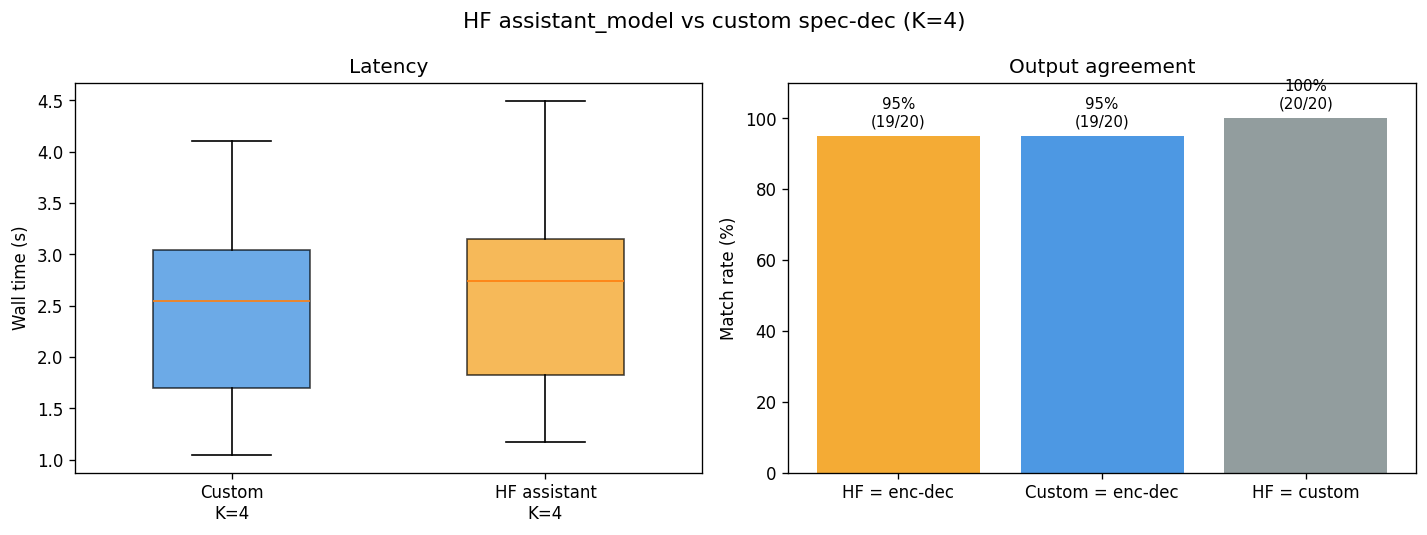

Saved /kaggle/working/benchmark_results/flexprofile/flexprofile_hf_comparison.png


In [15]:
# @title Part 2 — HF vs custom plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(f"HF assistant_model vs custom spec-dec (K={HF_K})", fontsize=13)

ax = axes[0]
t_cu = df_hf["t_custom"].dropna().values
t_hf = df_hf["t_hf"].dropna().values
if len(t_cu) and len(t_hf):
    bp = ax.boxplot([t_cu, t_hf], patch_artist=True, widths=0.5)
    for patch, c in zip(bp["boxes"], [BLUE, ORANGE]):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_xticklabels([f"Custom\nK={HF_K}", f"HF assistant\nK={HF_K}"])
ax.set_ylabel("Wall time (s)"); ax.set_title("Latency")

ax = axes[1]
labels = ["HF = enc-dec", "Custom = enc-dec", "HF = custom"]
counts = [n_ref, n_cu, n_hf_cu]
totals = [n_ok, len(df_hf), n_ok]
pcts = [100 * c / t if t else 0 for c, t in zip(counts, totals)]
bars = ax.bar(labels, pcts, color=[ORANGE, BLUE, GRAY], alpha=0.85)
ax.set_ylim(0, 110); ax.set_ylabel("Match rate (%)")
ax.set_title("Output agreement")
for bar, pct, c, t in zip(bars, pcts, counts, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{pct:.0f}%\n({c}/{t})", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "flexprofile_hf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {RESULTS_DIR / 'flexprofile_hf_comparison.png'}")

In [16]:
# @title Timing helpers

def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


@torch.inference_mode()
def time_encdec(aa_seq: str) -> float:
    """Median wall time for plain enc-dec greedy (3Di)."""
    for _ in range(NUM_WARMUP):
        enc_dec_greedy_3di(aa_seq)
    _sync()
    times = []
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        enc_dec_greedy_3di(aa_seq)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times)


@torch.inference_mode()
def time_spec_decode(aa_seq: str, K: int, prepared=None) -> tuple[float, dict]:
    """Median wall time + last spec-dec stats for FlexProfile drafter."""
    prepared = prepared if prepared is not None else _prepare_spec_inputs(aa_seq)
    kw = dict(
        K=K,
        profile_log_probs=prepared["profile_log_probs"],
        encoder_hidden=prepared["encoder_hidden"],
        enc_attn=prepared["enc_attn"],
    )
    for _ in range(NUM_WARMUP):
        speculative_decode_greedy(aa_seq, **kw)
    _sync()
    times, last = [], None
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        last = speculative_decode_greedy(aa_seq, **kw)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), last


print("Timing helpers defined.")


Timing helpers defined.


## Part 3 — Benchmarking

Measure real speedup across proteins and K values. Compare to baseline enc-dec timing.
Results checkpoint after each protein (resume-safe on Colab/Kaggle disconnect).


In [17]:
# @title Checkpointing
from datetime import datetime

def save_spec_checkpoint(state: dict):
    state["timestamp"] = datetime.now().isoformat()
    with open(CKPT_PATH, "wb") as f:
        pickle.dump(state, f)


def load_spec_checkpoint() -> dict | None:
    if CKPT_PATH.exists():
        with open(CKPT_PATH, "rb") as f:
            return pickle.load(f)
    return None


print(f"Spec-decode checkpoint: {CKPT_PATH}")


Spec-decode checkpoint: /kaggle/working/benchmark_results/flexprofile/checkpoints/flexprofile_spec_decode.pkl


In [18]:
# @title Main benchmark loop — FlexProfile drafter

ckpt = load_spec_checkpoint()
if ckpt is not None:
    results = ckpt["results"]
    completed = set(ckpt["completed"])
    print(f"Resuming: {len(completed)} tasks done.")
else:
    results = []
    completed = set()

sorted_data = sorted(benchmark_data, key=lambda x: x["length"])
total_tasks = len(sorted_data) * (1 + len(K_VALUES))
print(f"Total tasks: {len(sorted_data)} proteins × (1 enc-dec + {len(K_VALUES)} K) = {total_tasks}")
print(f"Already done: {len(completed)}, Remaining: {total_tasks - len(completed)}")

t_global_start = time.time()

for item in tqdm(sorted_data, desc="Benchmark"):
    uid, aa, L = item["id"], item["AA"], item["length"]

    key_enc = f"{uid}_encdec"
    if key_enc not in completed:
        t_enc = time_encdec(aa)
        results.append(dict(
            protein_id=uid, length=L, drafter="enc_dec", K=0,
            wall_s=t_enc, speedup=1.0,
            draft_acceptance_rate=None, mean_tps=1.0, n_steps=L,
        ))
        completed.add(key_enc)
        print(f"\n[{uid} L={L}]  enc-dec: {t_enc:.2f}s")
    else:
        t_enc = next(
            r["wall_s"] for r in results
            if r["protein_id"] == uid and r["drafter"] == "enc_dec"
        )

    # Reuse per-protein encoder/profile tensors across all K values.
    any_spec_pending = any(f"{uid}_flex_K{K}" not in completed for K in K_VALUES)
    prepared = _prepare_spec_inputs(aa) if any_spec_pending else None

    for K in K_VALUES:
        key = f"{uid}_flex_K{K}"
        if key in completed:
            continue
        t_spec, spec_res = time_spec_decode(aa, K, prepared=prepared)
        speedup = t_enc / t_spec if t_spec > 0 else float("nan")
        results.append(dict(
            protein_id=uid, length=L, drafter="flexprofile", K=K,
            wall_s=t_spec, speedup=speedup,
            draft_acceptance_rate=spec_res["draft_acceptance_rate"],
            step_first_token_rate=spec_res["step_first_token_rate"],
            mean_tps=spec_res["mean_tps"],
            n_steps=spec_res["n_steps"],
        ))
        completed.add(key)
        print(f"  flex K={K:2d}: {t_spec:.2f}s  speedup={speedup:.2f}x  "
              f"draft_accept={spec_res['draft_acceptance_rate']:.3f}")

    save_spec_checkpoint({"results": results, "completed": list(completed)})

    elapsed = time.time() - t_global_start
    done = len(completed)
    remaining = total_tasks - done
    if done > 0 and remaining > 0:
        eta_min = (elapsed / done) * remaining / 60
        print(f"  ETA: ~{eta_min:.0f} min")

print(f"\n{'='*60}")
print("BENCHMARK COMPLETE")


Total tasks: 20 proteins × (1 enc-dec + 4 K) = 100
Already done: 0, Remaining: 100


Benchmark:   0%|          | 0/20 [00:00<?, ?it/s]


[P01542 L=46]  enc-dec: 2.00s
  flex K= 1: 1.38s  speedup=1.45x  draft_accept=0.516
  flex K= 2: 1.27s  speedup=1.58x  draft_accept=0.316
  flex K= 4: 1.14s  speedup=1.76x  draft_accept=0.214
  flex K= 8: 1.14s  speedup=1.75x  draft_accept=0.114
  ETA: ~9 min

[P0A7N4 L=57]  enc-dec: 2.64s
  flex K= 1: 1.49s  speedup=1.77x  draft_accept=0.706
  flex K= 2: 1.21s  speedup=2.17x  draft_accept=0.585
  flex K= 4: 1.10s  speedup=2.39x  draft_accept=0.378
  flex K= 8: 0.94s  speedup=2.79x  draft_accept=0.259
  ETA: ~9 min

[P02798 L=61]  enc-dec: 2.72s
  flex K= 1: 1.98s  speedup=1.38x  draft_accept=0.409
  flex K= 2: 1.77s  speedup=1.53x  draft_accept=0.299
  flex K= 4: 1.74s  speedup=1.56x  draft_accept=0.163
  flex K= 8: 1.74s  speedup=1.56x  draft_accept=0.085
  ETA: ~9 min

[P61583 L=75]  enc-dec: 3.29s
  flex K= 1: 2.84s  speedup=1.16x  draft_accept=0.206
  flex K= 2: 2.85s  speedup=1.16x  draft_accept=0.104
  flex K= 4: 2.86s  speedup=1.15x  draft_accept=0.058
  flex K= 8: 2.87s  spee

## Part 4 — Analysis & Plots


In [19]:
# @title Aggregate results
df = pd.DataFrame(results)
df.to_csv(RESULTS_DIR / "flexprofile_spec_decode_results.csv", index=False)

encdec_df = df[df["drafter"] == "enc_dec"]
spec_df = df[df["drafter"] == "flexprofile"]

print("=== Speedup by K (flexprofile drafter) ===")
print(f"{'K':>7s}  {'Mean Speedup':>12s}  {'Median':>8s}  {'Draft accept':>12s}  {'Tok/step':>8s}")
print("-" * 55)
for K in K_VALUES:
    sub = spec_df[spec_df["K"] == K]
    if len(sub):
        print(f"{K:7d}  {sub['speedup'].mean():12.2f}  {sub['speedup'].median():8.2f}  "
              f"{sub['draft_acceptance_rate'].mean():12.3f}  {sub['mean_tps'].mean():8.2f}")

print(f"\nSaved {RESULTS_DIR / 'flexprofile_spec_decode_results.csv'}")


=== Speedup by K (flexprofile drafter) ===
      K  Mean Speedup    Median  Draft accept  Tok/step
-------------------------------------------------------
      1          1.54      1.56         0.594      1.59
      2          1.85      1.88         0.465      1.93
      4          2.16      2.17         0.319      2.26
      8          2.41      2.45         0.200      2.53

Saved /kaggle/working/benchmark_results/flexprofile/flexprofile_spec_decode_results.csv


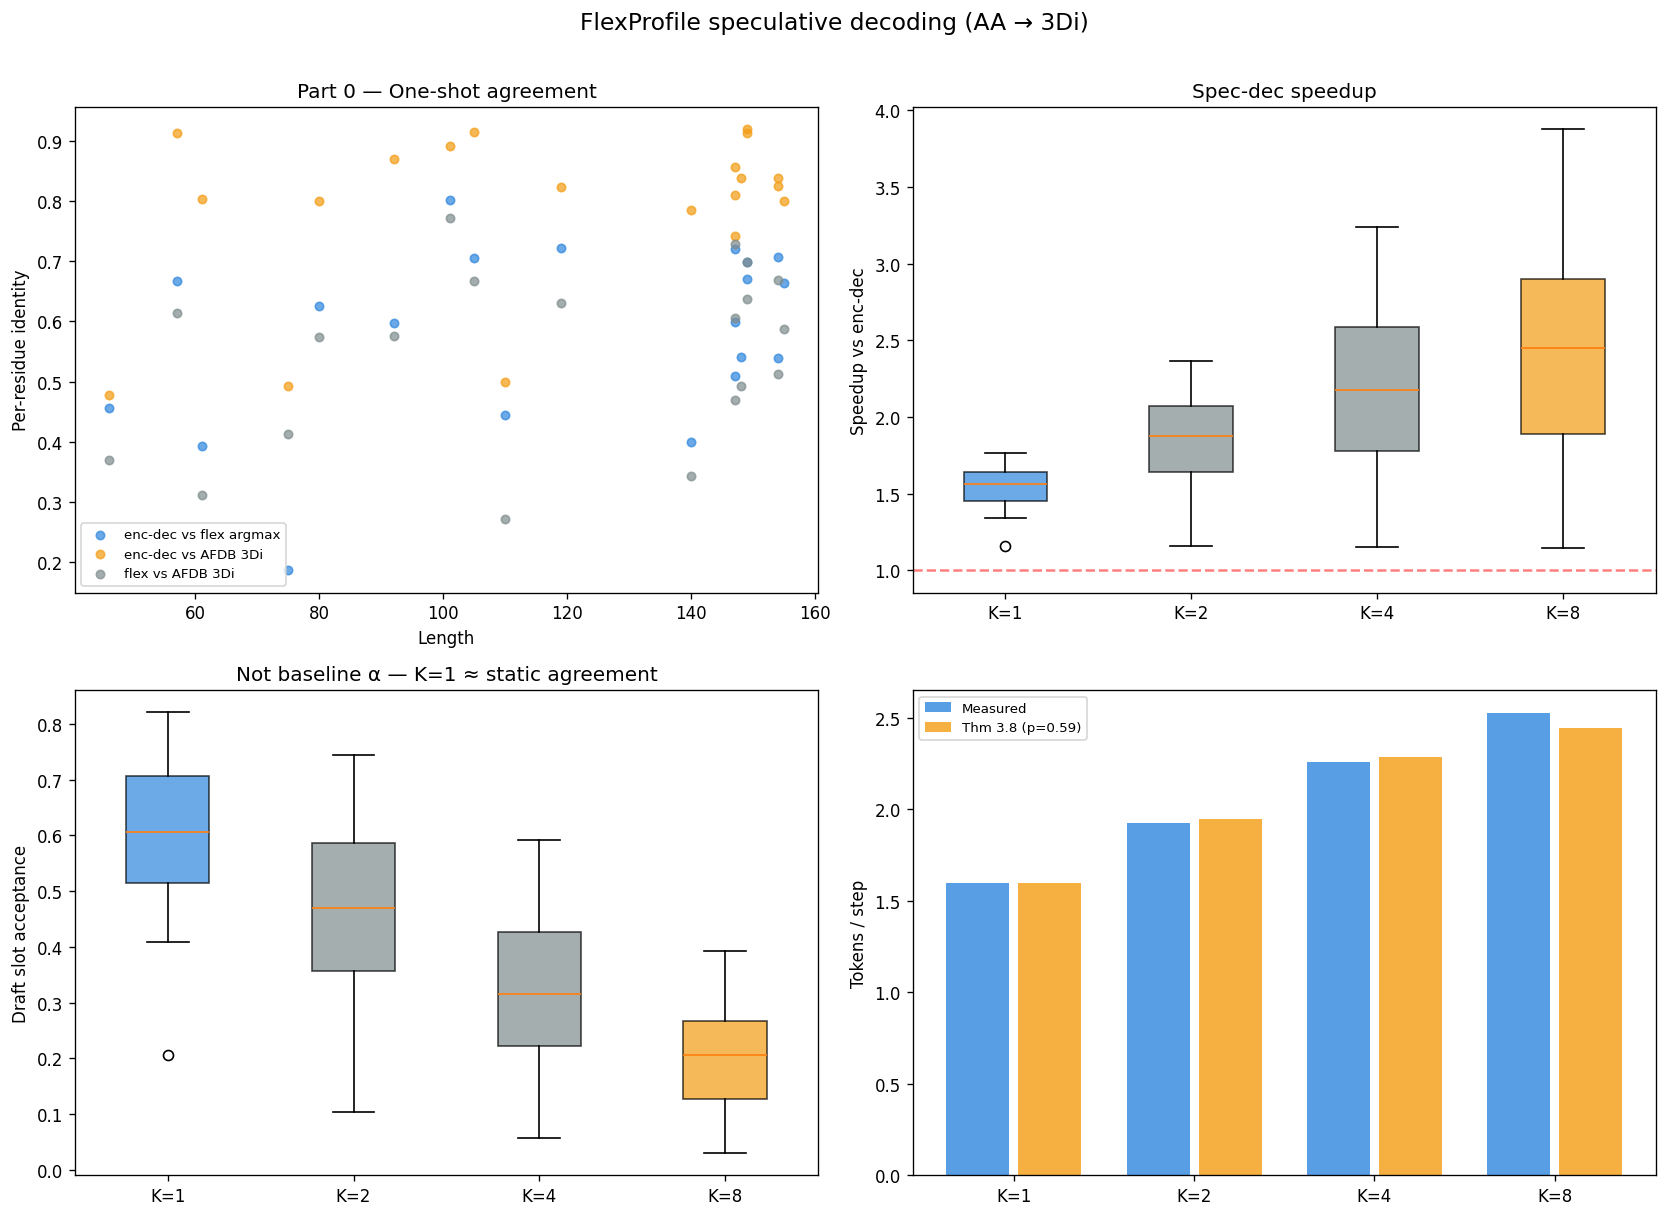

Saved /kaggle/working/benchmark_results/flexprofile/flexprofile_spec_decode_plots.png


In [20]:
# @title Plots: speedup, acceptance, Theorem 3.8
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("FlexProfile speculative decoding (AA → 3Di)", fontsize=14, y=1.01)
ax = axes[0, 0]
for label, col, c in [
    ("enc-dec vs flex argmax", "encdec_vs_flex_identity", BLUE),
    ("enc-dec vs AFDB 3Di", "encdec_vs_afdb_3di", ORANGE),
    ("flex vs AFDB 3Di", "flex_vs_afdb_3di", GRAY),
]:
    ax.scatter(df0["length"], df0[col], s=25, alpha=0.7, label=label, c=c)
ax.set_xlabel("Length"); ax.set_ylabel("Per-residue identity"); ax.legend(fontsize=8)
ax.set_title("Part 0 — One-shot agreement")

ax = axes[0, 1]
data = [spec_df[spec_df["K"] == K]["speedup"].values for K in K_VALUES]
bp = ax.boxplot(data, patch_artist=True)
for patch, K in zip(bp["boxes"], K_VALUES):
    patch.set_facecolor({1: BLUE, 8: ORANGE}.get(K, GRAY)); patch.set_alpha(0.7)
ax.set_xticklabels([f"K={K}" for K in K_VALUES])
ax.axhline(1.0, color="red", ls="--", alpha=0.5)
ax.set_ylabel("Speedup vs enc-dec"); ax.set_title("Spec-dec speedup")

ax = axes[1, 0]
data_ar = [spec_df[spec_df["K"] == K]["draft_acceptance_rate"].values for K in K_VALUES]
bp2 = ax.boxplot(data_ar, patch_artist=True)
for patch, K in zip(bp2["boxes"], K_VALUES):
    patch.set_facecolor({1: BLUE, 8: ORANGE}.get(K, GRAY)); patch.set_alpha(0.7)
ax.set_xticklabels([f"K={K}" for K in K_VALUES])
ax.set_ylabel("Draft slot acceptance"); ax.set_title("Not baseline α — K=1 ≈ static agreement")

ax = axes[1, 1]
if 1 in K_VALUES:
    p_geom = spec_df[spec_df["K"] == 1]["draft_acceptance_rate"].mean()
else:
    p_geom = 0.25
pred_tps = [(1 - p_geom**(K + 1)) / (1 - p_geom) if p_geom < 0.999 else K + 1 for K in K_VALUES]
meas = [spec_df[spec_df["K"] == K]["mean_tps"].mean() for K in K_VALUES]
x = np.arange(len(K_VALUES))
ax.bar(x - 0.2, meas, 0.35, label="Measured", color=BLUE, alpha=0.8)
ax.bar(x + 0.2, pred_tps, 0.35, label=f"Thm 3.8 (p={p_geom:.2f})", color=ORANGE, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"K={K}" for K in K_VALUES])
ax.set_ylabel("Tokens / step"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "flexprofile_spec_decode_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {RESULTS_DIR / 'flexprofile_spec_decode_plots.png'}")

## Part 5 — HF `assistant_model` benchmark (K sweep)

Standalone benchmark for `FlexProfileAssistantModel` via `model.generate(..., assistant_model=flex_assistant)` across all `K_VALUES`, with speedup vs enc-dec baseline.

**Run these cells first (skip everything else):**
1. pip install
2. Runtime paths
3. FlexProfile drafter utilities (`FlexProfileDrafter`, `FlexProfileAssistantModel`)
4. Imports
5. Configuration — set `NUM_PROTEINS = 100` (or `None` for full test set)
6. Load ProstT5 + ProtProfileMD
7. Load test set
8. Helpers (`_format_aa`, `enc_dec_greedy_3di`, `_sync`)
9. FlexProfileAssistantModel wrapper

**Then run all Part 5 cells below** (setup → timing → benchmark → aggregate → plots).

**Skip (slow / not needed):** Part 0 benchmark, Part 1 (spec-dec + correctness), Part 2 comparison loop & plots, **Part 3 benchmark loop**, Part 4, Timing helpers (Part 3).

Enc-dec baselines are reused from the Part 3 checkpoint (`flexprofile_spec_decode.pkl`) when available; otherwise timed on the fly in Part 5.


In [ ]:
# @title Part 5 — HF benchmark setup
from datetime import datetime

HF_CKPT_PATH = CHECKPOINT_DIR / "flexprofile_hf_spec_decode.pkl"
HF_RESULTS_CSV = RESULTS_DIR / "flexprofile_hf_spec_decode_results.csv"

# Reuse enc-dec wall times from Part 3 checkpoint when present (avoids re-timing baseline).
_encdec_cache: dict[str, float] = {}


def _load_encdec_cache_from_part3() -> int:
    ckpt = None
    if "load_spec_checkpoint" in globals():
        ckpt = load_spec_checkpoint()
    elif CKPT_PATH.exists():
        with open(CKPT_PATH, "rb") as f:
            ckpt = pickle.load(f)
    if not ckpt:
        return 0
    n = 0
    for row in ckpt.get("results", []):
        if row.get("drafter") == "enc_dec" and row.get("K", 0) == 0:
            uid = row["protein_id"]
            if uid not in _encdec_cache:
                _encdec_cache[uid] = row["wall_s"]
                n += 1
    return n


def _get_encdec_time(uid: str, aa: str) -> float:
    if uid in _encdec_cache:
        return _encdec_cache[uid]
    t = time_encdec(aa)
    _encdec_cache[uid] = t
    return t


n_cached = _load_encdec_cache_from_part3()
print(f"HF checkpoint: {HF_CKPT_PATH}")
print(f"Enc-dec baselines cached from Part 3: {n_cached} proteins")
print(f"Benchmark: {len(benchmark_data)} proteins × {len(K_VALUES)} K = {len(benchmark_data) * len(K_VALUES)} HF tasks")


In [ ]:
# @title Part 5 — HF timing helper

@torch.inference_mode()
def time_encdec(aa_seq: str) -> float:
    """Median wall time for plain enc-dec greedy (3Di)."""
    for _ in range(NUM_WARMUP):
        enc_dec_greedy_3di(aa_seq)
    _sync()
    times = []
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        enc_dec_greedy_3di(aa_seq)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times)


@torch.inference_mode()
def time_hf_assisted(aa_seq: str, K: int) -> tuple[float, str]:
    """Median wall time for HF assisted generation at draft length K."""
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    flex_assistant.generation_config.num_assistant_tokens = K
    kw = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        assistant_model=flex_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**kw)
    _sync()
    times = []
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**kw)
        _sync()
        times.append(time.perf_counter() - t0)
    pred = _decode_3di(out[0])[:L]
    return statistics.median(times), pred


def save_hf_checkpoint(state: dict):
    state["timestamp"] = datetime.now().isoformat()
    with open(HF_CKPT_PATH, "wb") as f:
        pickle.dump(state, f)


def load_hf_checkpoint() -> dict | None:
    if HF_CKPT_PATH.exists():
        with open(HF_CKPT_PATH, "rb") as f:
            return pickle.load(f)
    return None


print("HF timing + checkpoint helpers ready.")


In [ ]:
# @title Part 5 — Main benchmark loop (HF assistant_model)

ckpt = load_hf_checkpoint()
if ckpt is not None:
    hf_results = ckpt["results"]
    hf_completed = set(ckpt["completed"])
    print(f"Resuming HF benchmark: {len(hf_completed)} tasks done.")
else:
    hf_results = []
    hf_completed = set()

sorted_data = sorted(benchmark_data, key=lambda x: x["length"])
total_hf_tasks = len(sorted_data) * len(K_VALUES)
print(f"Total HF tasks: {len(sorted_data)} proteins × {len(K_VALUES)} K = {total_hf_tasks}")
print(f"Already done: {len(hf_completed)}, Remaining: {total_hf_tasks - len(hf_completed)}")

t_global_start = time.time()

for item in tqdm(sorted_data, desc="HF benchmark"):
    uid, aa, L = item["id"], item["AA"], item["length"]
    t_enc = _get_encdec_time(uid, aa)

    for K in K_VALUES:
        key = f"{uid}_hf_K{K}"
        if key in hf_completed:
            continue
        try:
            t_hf, _pred = time_hf_assisted(aa, K)
            hf_ok = True
        except Exception as exc:
            print(f"  {uid} K={K}: HF failed — {exc}")
            t_hf, hf_ok = float("nan"), False

        speedup = t_enc / t_hf if hf_ok and t_hf > 0 else float("nan")
        hf_results.append(dict(
            protein_id=uid, length=L, drafter="hf_assistant", K=K,
            wall_s=t_hf, speedup=speedup, hf_ok=hf_ok,
            enc_dec_wall_s=t_enc,
            draft_acceptance_rate=None,
            mean_tps=None,
            n_steps=None,
        ))
        hf_completed.add(key)
        if hf_ok:
            print(f"[{uid} L={L}]  HF K={K:2d}: {t_hf:.2f}s  speedup={speedup:.2f}x  (enc-dec {t_enc:.2f}s)")
        else:
            print(f"[{uid} L={L}]  HF K={K:2d}: FAILED")

    save_hf_checkpoint({"results": hf_results, "completed": list(hf_completed)})

    elapsed = time.time() - t_global_start
    done = len(hf_completed)
    remaining = total_hf_tasks - done
    if done > 0 and remaining > 0:
        eta_min = (elapsed / done) * remaining / 60
        print(f"  ETA: ~{eta_min:.0f} min")

print(f"\n{'='*60}")
print("HF BENCHMARK COMPLETE")


In [ ]:
# @title Part 5 — Aggregate HF results
hf_df = pd.DataFrame(hf_results)
hf_df.to_csv(HF_RESULTS_CSV, index=False)

hf_ok_df = hf_df[hf_df["hf_ok"] == True]  # noqa: E712

print("=== HF assistant_model speedup by K ===")
print(f"{'K':>7s}  {'Mean Speedup':>12s}  {'Median':>8s}  {'Mean wall (s)':>13s}  {'N ok':>5s}")
print("-" * 55)
for K in K_VALUES:
    sub = hf_ok_df[hf_ok_df["K"] == K]
    if len(sub):
        print(f"{K:7d}  {sub['speedup'].mean():12.2f}  {sub['speedup'].median():8.2f}  "
              f"{sub['wall_s'].mean():13.2f}  {len(sub):5d}")

n_fail = int((~hf_df["hf_ok"]).sum())
print(f"\nHF failures: {n_fail}/{len(hf_df)}")
print(f"Saved {HF_RESULTS_CSV}")


In [ ]:
# @title Part 5 — HF speedup plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("HF assistant_model speculative decoding (AA → 3Di)", fontsize=13)

ax = axes[0]
data = [hf_ok_df[hf_ok_df["K"] == K]["speedup"].values for K in K_VALUES]
bp = ax.boxplot(data, patch_artist=True)
for patch, K in zip(bp["boxes"], K_VALUES):
    patch.set_facecolor({1: BLUE, 8: ORANGE}.get(K, GRAY))
    patch.set_alpha(0.7)
ax.set_xticklabels([f"K={K}" for K in K_VALUES])
ax.axhline(1.0, color="red", ls="--", alpha=0.5)
ax.set_ylabel("Speedup vs enc-dec")
ax.set_title("HF speedup by K")

ax = axes[1]
for K in K_VALUES:
    sub = hf_ok_df[hf_ok_df["K"] == K]
    if len(sub):
        ax.scatter(sub["length"], sub["speedup"], s=20, alpha=0.6, label=f"K={K}")
ax.axhline(1.0, color="red", ls="--", alpha=0.4)
ax.set_xlabel("Protein length")
ax.set_ylabel("Speedup vs enc-dec")
ax.set_title("Per-protein HF speedup")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
hf_plot_path = RESULTS_DIR / "flexprofile_hf_spec_decode_plots.png"
plt.savefig(hf_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {hf_plot_path}")


<a href="/kaggle/working/benchmark_results/flexprofile/checkpoints/flexprofile_spec_decode.pkl"> Download File </a>

In [21]:
ls benchmark_results/flexprofile/checkpoints/

flexprofile_spec_decode.pkl


In [22]:
from IPython.display import FileLink

# Path to your file
file_path = 'benchmark_results/flexprofile/checkpoints/flexprofile_spec_decode.pkl'

# Generate and display the link
FileLink(file_path)

/kaggle/working/benchmark_results/flexprofile/checkpoints/flexprofile_spec_decode.pkl